# Mundiales 2018, 2022 y 2026
## Preparación de datos y entrada al análisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de información.

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('../datos')
pd.set_option('display.max_columns', 50)

## Cargar los tres archivos

In [2]:
d18 = pd.read_csv(DATA / 'mundial_2018_sucio.csv', dtype=str)
d22 = pd.read_csv(DATA / 'mundial_2022_sucio.csv', dtype=str)
d26 = pd.read_csv(DATA / 'mundial_2026_sucio.csv', dtype=str)

for nombre, df in [('2018', d18), ('2022', d22), ('2026', d26)]:
    print(nombre, df.shape)
    display(df.head())


2018 (50, 16)


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,grupos,group-b,1,06/15/2018,18:00,Morocco,"Iran, I.R.",0,1,0 : 1,FALSE,Krestovsky Stadium,Saint Petersburg,https://github.com/jfjelstul/worldcup
3,M-2018-04,2018,1ra fase,Grupo B,1,15-06-18,21:00,Portugal,España,3,3,3 x 3,no,Fisht Olympic Stadium,Sochi,https://github.com/jfjelstul/worldcup
4,M-2018-05,2018,Fase de grupos,C,1,"Jun 16, 2018",13:00,France,Australia,2,1,2—1,No,Kazan Arena,Kazan,https://github.com/jfjelstul/worldcup


2022 (51, 16)


,match_id,WorldCup,stage,group_name,match_day,date,local,visitor,home_score,away_score,score_text,home_host,venue,city_name,comentario,source_url
0,M-2022-01,2022,group,Group A,1,2022-11-20,Qatar,Ecuador,NaN,2,0 : 2,1,Al Bayt Stadium,Al Khor,ok,https://github.com/jfjelstul/worldcup
1,M-2022-02,2022,Group Stage,B,1,21/11/2022,England,IR Iran,6,2,6 x 2,FALSE,Khalifa International Stadium,Al Rayyan,NaN,https://github.com/jfjelstul/worldcup
2,M-2022-03,2022,Fase grupos,Grupo A,1,11/21/2022,Senegal,Netherlands,0,2,0—2,no,Al Thumama Stadium,Doha,revisar,https://github.com/jfjelstul/worldcup
3,M-2022-04,2022,group,B,1,21-11-22,United States,Wales,1,1,1-1,No,Ahmad bin Ali Stadium,Al Rayyan,dato importado,https://github.com/jfjelstul/worldcup
4,M-2022-05,2022,Group Stage,Group C,1,"Nov 22, 2022",Argentina,KSA,1,2,1–2,0,Lusail Stadium,Lusail,ok,https://github.com/jfjelstul/worldcup


2026 (75, 14)


,match,wc,round,grp,md,played_on,home,away,HG,AG,result_raw,host_h,host_a,source
0,M-2026-001,2026,GS,A,1,2026-06-11,México,South Africa,NaN,s/d,2–0,TRUE,no,https://en.wikipedia.org/wiki/2026_FIFA_World_...
1,M-2026-002,2026,group stage,Grupo A,1,12/06/2026,Korea Rep.,Czech Republic,2,1,2 : 1,no,No,https://en.wikipedia.org/wiki/2026_FIFA_World_...
2,M-2026-007,2026,fase de grupos,group-b,1,06/12/2026,Canada,BOSNIA & HERZEGOVINA,1,1,1 x 1,Sí,0,https://en.wikipedia.org/wiki/2026_FIFA_World_...
3,M-2026-008,2026,GS,B,1,13-06-26,Qatar,Suisse,1,1,1—1,0,FALSE,https://en.wikipedia.org/wiki/2026_FIFA_World_...
4,M-2026-013,2026,group stage,C,1,"Jun 13, 2026",Brazil,Morocco,1,1,1-1,FALSE,no,https://en.wikipedia.org/wiki/2026_FIFA_World_...


## Perfilado

Para cada archivo revisa:

- columnas;
- tipos;
- valores nulos;
- duplicados;
- valores únicos de grupos, fases y equipos;
- goles que no puedan convertirse directamente a número.

In [3]:
def perfil(df, nombre):
    print(f'\n=== Perfil {nombre} ===')
    print('Dimensiones:', df.shape)
    print('Nulos por columna:')
    print(df.isna().sum())
    print('Filas totalmente duplicadas:', df.duplicated().sum())

    for col in df.columns:
        etiqueta = col.lower()
        if any(p in etiqueta for p in ('grupo', 'group', 'grp', 'fase', 'stage', 'round')):
            print(f'Valores únicos en {col!r}:', sorted(df[col].dropna().unique().tolist()))

    for col in df.columns:
        if any(p in col.lower() for p in ('gol', 'score')) or col in ('HG', 'AG'):
            numerico = pd.to_numeric(df[col], errors='coerce')
            no_convertible = df[col][numerico.isna() & df[col].notna()]
            if len(no_convertible):
                print(f'{col!r}: valores que no son número directo ->', no_convertible.unique().tolist())

perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')



=== Perfil 2018 ===
Dimensiones: (50, 16)
Nulos por columna:
ID Partido          0
Año                 0
Fase                0
Grupo               1
Jornada             0
Fecha               0
Hora                0
Equipo Local        0
Equipo Visitante    0
Goles Local         0
Goles Visitante     3
Marcador            1
Anfitrión Local     0
Estadio             0
Ciudad              0
Fuente              0
dtype: int64
Filas totalmente duplicadas: 2
Valores únicos en 'Fase': ['1ra fase', 'Fase de grupos', 'GROUP STAGE', 'grupos']
Valores únicos en 'Grupo': ['A ', 'B ', 'C ', 'D ', 'E ', 'F ', 'G ', 'Grupo A', 'Grupo B', 'Grupo C', 'Grupo D', 'Grupo E', 'Grupo F', 'Grupo G', 'Grupo H', 'group-a', 'group-b', 'group-c', 'group-d', 'group-e', 'group-f', 'group-g', 'group-h', 's/d']
'Goles Local': valores que no son número directo -> ['5 goles', '1 goles']

=== Perfil 2022 ===
Dimensiones: (51, 16)
Nulos por columna:
match_id       0
WorldCup       0
stage          0
group_name     1
ma

## Unificar nombres de columnas

In [4]:
rename_maps = {
    2018: {
        'ID Partido': 'partido_id', 'Fase': 'fase', 'Grupo': 'grupo',
        'Jornada': 'jornada', 'Fecha': 'fecha', 'Equipo Local': 'equipo_local',
        'Equipo Visitante': 'equipo_visitante', 'Goles Local': 'goles_local',
        'Goles Visitante': 'goles_visitante', 'Marcador': 'marcador',
        'Anfitrión Local': 'local_es_anfitrion', 'Fuente': 'fuente',
    },
    2022: {
        'match_id': 'partido_id', 'stage': 'fase', 'group_name': 'grupo',
        'match_day': 'jornada', 'date': 'fecha', 'local': 'equipo_local',
        'visitor': 'equipo_visitante', 'home_score': 'goles_local',
        'away_score': 'goles_visitante', 'score_text': 'marcador',
        'home_host': 'local_es_anfitrion', 'source_url': 'fuente',
    },
    2026: {
        'match': 'partido_id', 'round': 'fase', 'grp': 'grupo', 'md': 'jornada',
        'played_on': 'fecha', 'home': 'equipo_local', 'away': 'equipo_visitante',
        'HG': 'goles_local', 'AG': 'goles_visitante', 'result_raw': 'marcador',
        'host_h': 'local_es_anfitrion', 'host_a': 'visitante_es_anfitrion',
        'source': 'fuente',
    },
}

# Esquema canónico mínimo:
columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]


## Normalizar equipos

No conviene borrar acentos del nombre que se mostrará. Crea una clave auxiliar sin acentos, minúscula y sin signos para buscar en el catálogo.

In [5]:
catalogo = pd.read_csv(DATA / 'catalogo_equipos.csv')

def clave_texto(valor):
    # Sin acentos, en minúsculas y sin signos, para que la búsqueda no dependa del formato original.
    if pd.isna(valor):
        return ''
    texto = unicodedata.normalize('NFKD', str(valor).strip().lower())
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return re.sub(r'[^a-z0-9]+', ' ', texto).strip()

mapa_equipos = {
    clave_texto(variante): canonico
    for variante, canonico in zip(catalogo['variante'], catalogo['nombre_canonico'])
}

incidencias = []  # bitácora de problemas y decisiones

def normalizar_equipo(valor):
    clave = clave_texto(valor)
    if clave in mapa_equipos:
        return mapa_equipos[clave]
    incidencias.append(f"Equipo sin coincidencia en el catálogo: '{valor}' (clave='{clave}').")
    return str(valor).strip() if pd.notna(valor) else np.nan


## Fechas, grupos, booleanos y marcadores

In [6]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}

FORMATOS_FECHA = ['%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y', '%d-%m-%y', '%b %d, %Y']
SEPARADOR_MARCADOR = re.compile(r'\s*[-–—:xX]\s*')
VALORES_VERDADEROS = {'si', 'sí', 'true', '1', 'yes'}

def convertir_fecha(valor, mundial):
    # 1. reconoce seriales de Excel (origen 1899-12-30);
    # 2. prueba varios formatos de texto;
    # 3. elige la fecha que cae dentro del rango del torneo.
    if pd.isna(valor):
        return pd.NaT
    texto = str(valor).strip()
    if texto == '' or texto.lower() in ('nan', 'n/d', 's/d'):
        return pd.NaT

    lo, hi = (pd.Timestamp(x) for x in rangos[mundial])

    if re.fullmatch(r'\d+', texto):
        fecha = pd.Timestamp('1899-12-30') + pd.to_timedelta(int(texto), unit='D')
        if not (lo <= fecha <= hi):
            incidencias.append(f'Fecha serial fuera de rango para {mundial}: {texto} -> {fecha.date()}.')
        return fecha

    candidatas = []
    for fmt in FORMATOS_FECHA:
        fecha = pd.to_datetime(texto, format=fmt, errors='coerce')
        if pd.notna(fecha):
            candidatas.append(fecha)

    for fecha in candidatas:
        if lo <= fecha <= hi:
            return fecha
    if candidatas:
        incidencias.append(f"Fecha '{texto}' ({mundial}) fuera de rango; se usa {candidatas[0].date()}.")
        return candidatas[0]
    incidencias.append(f"Fecha no reconocida para {mundial}: '{texto}'.")
    return pd.NaT

def extraer_numero(valor):
    # Devuelve el primer entero (puede ser negativo) o NaN si no hay ninguno.
    if pd.isna(valor):
        return np.nan
    m = re.search(r'-?\d+', str(valor))
    return float(m.group()) if m else np.nan

def separar_marcador(valor):
    # Acepta -, –, —, :, x o X como separador entre goles.
    if pd.isna(valor):
        return np.nan, np.nan
    partes = [p for p in SEPARADOR_MARCADOR.split(str(valor).strip()) if p != '']
    if len(partes) != 2:
        return np.nan, np.nan
    try:
        return float(partes[0]), float(partes[1])
    except ValueError:
        return np.nan, np.nan

def normalizar_grupo(valor):
    # Extrae una letra A-L aislada (evita falsos positivos como la G de GROUP).
    if pd.isna(valor):
        return np.nan
    m = re.search(r'\b([A-L])\b', str(valor).strip().upper())
    return m.group(1) if m else np.nan

def normalizar_booleano(valor):
    # Reconoce Sí, 1, TRUE, si, etc.; cualquier otra cosa (incluido vacío) es False.
    if pd.isna(valor):
        return False
    return str(valor).strip().lower() in VALORES_VERDADEROS


## Función de limpieza reproducible

In [7]:
def limpiar_mundial(df_crudo, mundial):
    df = df_crudo.rename(columns=rename_maps[mundial])
    for columna in columnas_base:
        if columna not in df.columns:
            df[columna] = np.nan
    df = df[columnas_base].copy()

    df['partido_id'] = df['partido_id'].str.strip()
    df['mundial'] = mundial
    df['fase'] = 'Fase de grupos'  # el kit solo usa fase de grupos; las variantes no aportan información
    df['fuente'] = df['fuente'].astype(str).str.strip()

    duplicados = df.duplicated(subset=['partido_id'], keep='first')
    if duplicados.any():
        incidencias.append(f"{mundial}: se eliminaron {int(duplicados.sum())} filas duplicadas "
                            f"({df.loc[duplicados, 'partido_id'].tolist()}).")
    df = df.loc[~duplicados].copy()

    df['equipo_local'] = df['equipo_local'].apply(normalizar_equipo)
    df['equipo_visitante'] = df['equipo_visitante'].apply(normalizar_equipo)

    df['grupo'] = df['grupo'].apply(normalizar_grupo)
    df['jornada'] = df['jornada'].apply(extraer_numero)
    df['fecha'] = df['fecha'].apply(lambda v: convertir_fecha(v, mundial))

    df['local_es_anfitrion'] = df['local_es_anfitrion'].apply(normalizar_booleano)
    df['visitante_es_anfitrion'] = df['visitante_es_anfitrion'].apply(normalizar_booleano)
    if mundial in (2018, 2022):
        incidencias.append(f'{mundial}: la fuente no distingue anfitrión del visitante; se asume False '
                            '(el anfitrión siempre figura como local en estos datos).')

    # Reparar goles con el marcador (Paso 7 de la guía).
    goles_local_bruto = df['goles_local'].apply(extraer_numero)
    goles_visita_bruto = df['goles_visitante'].apply(extraer_numero)
    marcador_local, marcador_visita = zip(*df['marcador'].apply(separar_marcador))
    marcador_local = pd.Series(marcador_local, index=df.index)
    marcador_visita = pd.Series(marcador_visita, index=df.index)
    tiene_marcador = marcador_local.notna() & marcador_visita.notna()

    conflicto = (
        tiene_marcador & goles_local_bruto.notna() & goles_visita_bruto.notna()
        & ((marcador_local != goles_local_bruto) | (marcador_visita != goles_visita_bruto))
    )
    for pid in df.loc[conflicto, 'partido_id']:
        incidencias.append(f'Partido {pid}: el marcador y los goles por separado no coinciden; se usó el marcador.')

    goles_local = marcador_local.where(tiene_marcador, goles_local_bruto)
    goles_visitante = marcador_visita.where(tiene_marcador, goles_visita_bruto)

    negativos = ((goles_local < 0) | (goles_visitante < 0)).fillna(False)
    for pid in df.loc[negativos, 'partido_id']:
        incidencias.append(f'Partido {pid}: goles negativos detectados; se descartan como inválidos.')
    df['goles_local'] = goles_local.mask(negativos)
    df['goles_visitante'] = goles_visitante.mask(negativos)

    validos = df['goles_local'].notna() & df['goles_visitante'].notna()
    df['marcador'] = np.where(
        validos,
        df['goles_local'].fillna(0).astype(int).astype(str) + '-' + df['goles_visitante'].fillna(0).astype(int).astype(str),
        np.nan,
    )

    # Inferir grupos faltantes a partir de los equipos que sí tienen grupo conocido.
    equipo_a_grupo = {}
    for _, fila in df.dropna(subset=['grupo']).iterrows():
        equipo_a_grupo.setdefault(fila['equipo_local'], fila['grupo'])
        equipo_a_grupo.setdefault(fila['equipo_visitante'], fila['grupo'])

    def inferir_grupo(fila):
        if pd.notna(fila['grupo']):
            return fila['grupo']
        grupo = equipo_a_grupo.get(fila['equipo_local']) or equipo_a_grupo.get(fila['equipo_visitante'])
        if grupo:
            incidencias.append(f"Partido {fila['partido_id']}: grupo inferido ({grupo}) a partir de los equipos.")
        else:
            incidencias.append(f"Partido {fila['partido_id']}: no fue posible inferir el grupo.")
        return grupo

    df['grupo'] = df.apply(inferir_grupo, axis=1)

    df['goles_totales'] = df['goles_local'] + df['goles_visitante']
    df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']

    resultado = np.select(
        [df['goles_local'] > df['goles_visitante'], df['goles_local'] == df['goles_visitante']],
        ['Gana', 'Empata'],
        default='Pierde',
    )
    resultado = pd.Series(resultado, index=df.index)
    resultado[~validos] = np.nan
    df['resultado_local'] = resultado

    return df.reset_index(drop=True)

limpio18 = limpiar_mundial(d18, 2018)
limpio22 = limpiar_mundial(d22, 2022)
limpio26 = limpiar_mundial(d26, 2026)
partidos = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)
partidos.shape


(168, 17)

## Validaciones obligatorias

La limpieza no termina cuando el código deja de producir errores. Debes comprobar invariantes.

In [8]:
print('=== Validaciones ===')
conteo = partidos.groupby('mundial').size().to_dict()
esperado = {2018: 48, 2022: 48, 2026: 72}
for mundial, n in esperado.items():
    obtenido = conteo.get(mundial, 0)
    print(f'{mundial}: {obtenido} partidos (esperado {n}) ->', 'OK' if obtenido == n else 'FALLA')

print('Duplicados por partido_id:', int(partidos.duplicated(subset=["partido_id"]).sum()))
print('Goles negativos:', int(((partidos['goles_local'] < 0) | (partidos['goles_visitante'] < 0)).sum()))

nulos = partidos[['equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'grupo']].isna().sum()
print('Nulos en columnas clave:')
print(nulos)

marcador_calc = np.where(
    partidos['goles_local'].notna() & partidos['goles_visitante'].notna(),
    partidos['goles_local'].fillna(0).astype(int).astype(str) + '-'
    + partidos['goles_visitante'].fillna(0).astype(int).astype(str),
    np.nan,
)
print('Marcador inconsistente con goles:', int((marcador_calc != partidos['marcador']).sum()))
print('Partidos con más de una fila:', int((partidos.groupby('partido_id').size() > 1).sum()))

print('\n=== Bitácora de incidencias ===')
for n, msg in enumerate(incidencias, 1):
    print(f'{n}. {msg}')


=== Validaciones ===
2018: 48 partidos (esperado 48) -> OK
2022: 48 partidos (esperado 48) -> OK
2026: 72 partidos (esperado 72) -> OK
Duplicados por partido_id: 0
Goles negativos: 0
Nulos en columnas clave:
equipo_local        0
equipo_visitante    0
goles_local         0
goles_visitante     0
grupo               0
dtype: int64
Marcador inconsistente con goles: 0
Partidos con más de una fila: 0

=== Bitácora de incidencias ===
1. 2018: se eliminaron 2 filas duplicadas (['M-2018-05', 'M-2018-18']).
2. 2018: la fuente no distingue anfitrión del visitante; se asume False (el anfitrión siempre figura como local en estos datos).
3. Partido M-2018-23: el marcador y los goles por separado no coinciden; se usó el marcador.
4. Partido M-2018-10: grupo inferido (F) a partir de los equipos.
5. 2022: se eliminaron 3 filas duplicadas (['M-2022-03', 'M-2022-03', 'M-2022-42']).
6. 2022: la fuente no distingue anfitrión del visitante; se asume False (el anfitrión siempre figura como local en estos da

## Comparación de los Mundiales

,partidos,goles,goles_por_partido,empates,porcentaje_empates,porcentaje_victorias_anfitrion,porcentaje_mas_2_5_goles
mundial,,,,,,,
2018,48,122.0,2.541667,9,18.750000,4.166667,50.000000
2022,48,120.0,2.500000,10,20.833333,0.000000,39.583333
2026,72,215.0,2.986111,20,27.777778,8.333333,55.555556


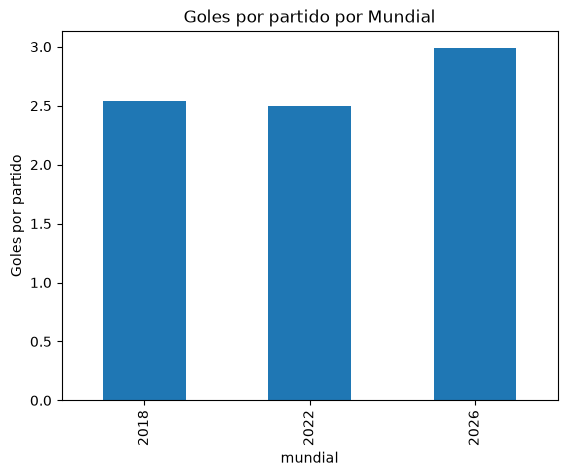

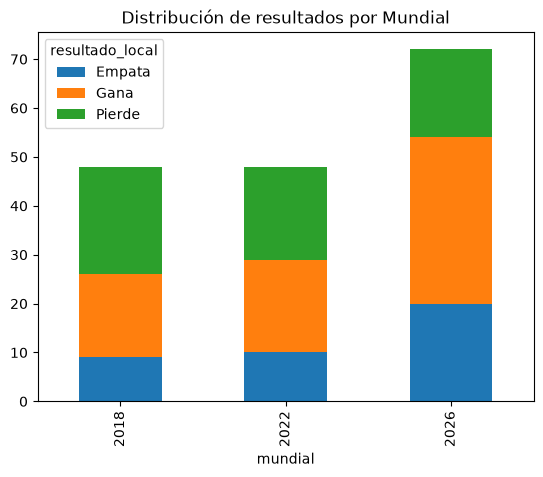

In [9]:
resumen = partidos.groupby('mundial').agg(partidos=('partido_id', 'count'), goles=('goles_totales', 'sum'))
resumen['goles_por_partido'] = resumen['goles'] / resumen['partidos']
resumen['empates'] = partidos.groupby('mundial')['resultado_local'].apply(lambda s: (s == 'Empata').sum())
resumen['porcentaje_empates'] = resumen['empates'] / resumen['partidos'] * 100

gano_anfitrion = (
    (partidos['local_es_anfitrion'] & (partidos['resultado_local'] == 'Gana'))
    | (partidos['visitante_es_anfitrion'] & (partidos['resultado_local'] == 'Pierde'))
)
resumen['porcentaje_victorias_anfitrion'] = gano_anfitrion.groupby(partidos['mundial']).mean() * 100
resumen['porcentaje_mas_2_5_goles'] = (partidos['goles_totales'] > 2.5).groupby(partidos['mundial']).mean() * 100
display(resumen)

# No comparamos únicamente goles totales: 2026 tiene más partidos (72) que 2018/2022 (48).
fig, ax = plt.subplots()
resumen['goles_por_partido'].plot(kind='bar', ax=ax, title='Goles por partido por Mundial')
ax.set_ylabel('Goles por partido')
plt.show()

fig, ax = plt.subplots()
partidos.groupby(['mundial', 'resultado_local']).size().unstack().plot(
    kind='bar', stacked=True, ax=ax, title='Distribución de resultados por Mundial')
plt.show()


## Tabla por equipo

In [10]:
local = partidos.rename(columns={
    'equipo_local': 'equipo', 'goles_local': 'gf', 'goles_visitante': 'gc',
})[['mundial', 'equipo', 'gf', 'gc', 'resultado_local']].copy()
local['resultado'] = local['resultado_local']

visita = partidos.rename(columns={
    'equipo_visitante': 'equipo', 'goles_visitante': 'gf', 'goles_local': 'gc',
})[['mundial', 'equipo', 'gf', 'gc', 'resultado_local']].copy()
visita['resultado'] = visita['resultado_local'].map({'Gana': 'Pierde', 'Pierde': 'Gana', 'Empata': 'Empata'})

apariciones = pd.concat([local, visita], ignore_index=True).drop(columns='resultado_local')
apariciones['pts'] = apariciones['resultado'].map({'Gana': 3, 'Empata': 1, 'Pierde': 0})

tabla_equipos = apariciones.groupby(['mundial', 'equipo']).agg(
    pj=('resultado', 'count'),
    pg=('resultado', lambda s: (s == 'Gana').sum()),
    pe=('resultado', lambda s: (s == 'Empata').sum()),
    pp=('resultado', lambda s: (s == 'Pierde').sum()),
    gf=('gf', 'sum'),
    gc=('gc', 'sum'),
    pts=('pts', 'sum'),
).reset_index()
tabla_equipos['dg'] = tabla_equipos['gf'] - tabla_equipos['gc']
tabla_equipos['pts_por_partido'] = tabla_equipos['pts'] / tabla_equipos['pj']
tabla_equipos = tabla_equipos.sort_values(['mundial', 'pts', 'dg'], ascending=[True, False, False])
tabla_equipos.head(10)


,mundial,equipo,pj,pg,pe,pp,gf,gc,pts,dg,pts_por_partido
2,2018,Belgium,3,3,0,0,9.0,2.0,9,7.0,3.000000
6,2018,Croatia,3,3,0,0,7.0,1.0,9,6.0,3.000000
31,2018,Uruguay,3,3,0,0,5.0,0.0,9,5.0,3.000000
3,2018,Brazil,3,2,1,0,5.0,1.0,7,4.0,2.333333
10,2018,France,3,2,1,0,3.0,1.0,7,2.0,2.333333
9,2018,England,3,2,0,1,8.0,3.0,6,5.0,2.000000
22,2018,Russia,3,2,0,1,8.0,4.0,6,4.0,2.000000
4,2018,Colombia,3,2,0,1,5.0,2.0,6,3.0,2.000000
28,2018,Sweden,3,2,0,1,5.0,2.0,6,3.0,2.000000
15,2018,Mexico,3,2,0,1,3.0,4.0,6,-1.0,2.000000


## Variables previas al partido

Para predecir no podemos utilizar datos ocurridos después del inicio. Crearemos promedios acumulados antes de cada encuentro.

In [11]:
def construir_variables_previas(partidos):
    partidos = partidos.sort_values(['mundial', 'fecha', 'jornada', 'partido_id']).reset_index(drop=True)
    estado = {}
    filas = []

    def promedios(e):
        if e['pj'] == 0:
            return 0.0, 0.0, 0.0
        return e['pts'] / e['pj'], (e['gf'] - e['gc']) / e['pj'], e['gf'] / e['pj']

    for _, partido in partidos.iterrows():
        clave_local = (partido['mundial'], partido['equipo_local'])
        clave_visita = (partido['mundial'], partido['equipo_visitante'])
        est_local = estado.setdefault(clave_local, {'pj': 0, 'pts': 0, 'gf': 0, 'gc': 0})
        est_visita = estado.setdefault(clave_visita, {'pj': 0, 'pts': 0, 'gf': 0, 'gc': 0})

        # Guardamos los promedios ANTES de sumar el partido actual: así no hay fuga de información.
        local_pts_prom_pre, local_gd_prom_pre, local_gf_prom_pre = promedios(est_local)
        visita_pts_prom_pre, visita_gd_prom_pre, visita_gf_prom_pre = promedios(est_visita)

        filas.append({
            'partido_id': partido['partido_id'],
            'mundial': partido['mundial'],
            'jornada': partido['jornada'],
            'local_pts_prom_pre': local_pts_prom_pre,
            'visita_pts_prom_pre': visita_pts_prom_pre,
            'local_gd_prom_pre': local_gd_prom_pre,
            'visita_gd_prom_pre': visita_gd_prom_pre,
            'local_gf_prom_pre': local_gf_prom_pre,
            'visita_gf_prom_pre': visita_gf_prom_pre,
            'local_es_anfitrion': int(partido['local_es_anfitrion']),
            'visitante_es_anfitrion': int(partido['visitante_es_anfitrion']),
            'goles_local': partido['goles_local'],
            'goles_visitante': partido['goles_visitante'],
            'diferencia_goles': partido['diferencia_goles'],
            'resultado_local': partido['resultado_local'],
        })

        pts_local = 3 if partido['resultado_local'] == 'Gana' else (1 if partido['resultado_local'] == 'Empata' else 0)
        pts_visita = 3 if partido['resultado_local'] == 'Pierde' else (1 if partido['resultado_local'] == 'Empata' else 0)

        est_local['pj'] += 1
        est_local['pts'] += pts_local
        est_local['gf'] += partido['goles_local']
        est_local['gc'] += partido['goles_visitante']

        est_visita['pj'] += 1
        est_visita['pts'] += pts_visita
        est_visita['gf'] += partido['goles_visitante']
        est_visita['gc'] += partido['goles_local']

    return pd.DataFrame(filas).dropna(subset=['resultado_local'])

features_df = construir_variables_previas(partidos)
features_df.head()


,partido_id,mundial,jornada,local_pts_prom_pre,visita_pts_prom_pre,local_gd_prom_pre,visita_gd_prom_pre,local_gf_prom_pre,visita_gf_prom_pre,local_es_anfitrion,visitante_es_anfitrion,goles_local,goles_visitante,diferencia_goles,resultado_local
0,M-2018-01,2018,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,5.0,0.0,5.0,Gana
1,M-2018-02,2018,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,1.0,-1.0,Pierde
2,M-2018-03,2018,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,1.0,-1.0,Pierde
3,M-2018-04,2018,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,3.0,3.0,0.0,Empata
4,M-2018-05,2018,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,2.0,1.0,1.0,Gana


## Entrenamiento y prueba


=== sin fuga ===
Línea base (siempre Pierde): 0.250
Árbol de decisión: 0.458


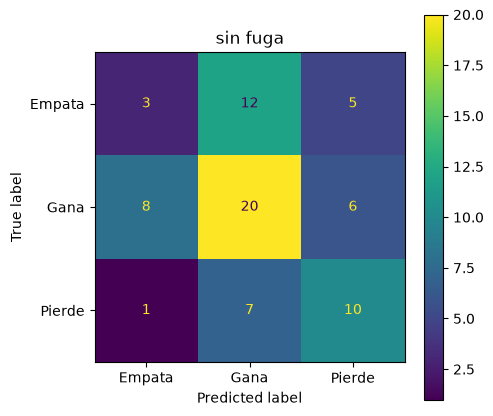

In [12]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre', 'visita_gd_prom_pre',
    'local_gf_prom_pre', 'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]

def entrenar_y_evaluar(features_df, columnas_extra=None, titulo='modelo'):
    columnas = features + (columnas_extra or [])
    entrenamiento = features_df[features_df['mundial'].isin([2018, 2022])]
    prueba = features_df[features_df['mundial'] == 2026]

    X_train, y_train = entrenamiento[columnas], entrenamiento['resultado_local']
    X_test, y_test = prueba[columnas], prueba['resultado_local']

    linea_base = y_train.value_counts(normalize=True).idxmax()
    exactitud_base = accuracy_score(y_test, [linea_base] * len(y_test))

    modelo = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    exactitud = accuracy_score(y_test, pred)

    print(f'\n=== {titulo} ===')
    print(f'Línea base (siempre {linea_base}): {exactitud_base:.3f}')
    print(f'Árbol de decisión: {exactitud:.3f}')

    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax)
    ax.set_title(titulo)
    plt.show()

    return modelo, exactitud_base, exactitud

modelo_sin_fuga, base_sin_fuga, exactitud_sin_fuga = entrenar_y_evaluar(features_df, titulo='sin fuga')


## Experimento de fuga de información

Agrega temporalmente `goles_local`, `goles_visitante` y `diferencia_goles` como variables. Si la precisión sube de forma extrema, explica por qué el modelo no está prediciendo realmente.


=== con fuga ===
Línea base (siempre Pierde): 0.250
Árbol de decisión: 1.000


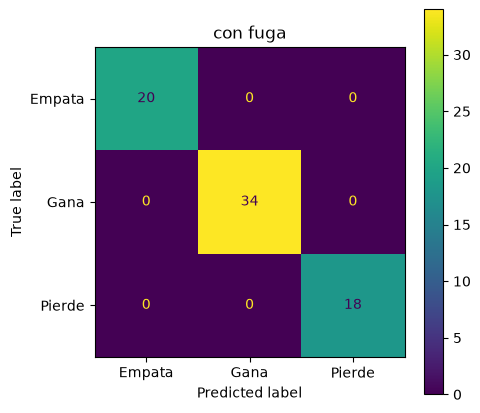


Sin fuga: 0.458 (línea base 0.250)
Con fuga: 1.000 (línea base 0.250)
La precisión con fuga sube de forma extrema porque goles_local/goles_visitante/diferencia_goles
ya contienen el resultado del partido: el árbol no está prediciendo, está leyendo la respuesta.


In [13]:
modelo_con_fuga, base_con_fuga, exactitud_con_fuga = entrenar_y_evaluar(
    features_df,
    columnas_extra=['goles_local', 'goles_visitante', 'diferencia_goles'],
    titulo='con fuga',
)

print(f'\nSin fuga: {exactitud_sin_fuga:.3f} (línea base {base_sin_fuga:.3f})')
print(f'Con fuga: {exactitud_con_fuga:.3f} (línea base {base_con_fuga:.3f})')
print('La precisión con fuga sube de forma extrema porque goles_local/goles_visitante/diferencia_goles')
print('ya contienen el resultado del partido: el árbol no está prediciendo, está leyendo la respuesta.')


## Reflexión final

**¿Qué problema de calidad fue el más difícil?**
Reconciliar el marcador de texto con los goles separados: había formatos de separador distintos (`-`, `–`, `—`, `:`, `x`), goles en texto ("5 goles"), vacíos y hasta un valor negativo. Hubo que definir una regla de prioridad clara (el marcador gana sobre los goles sueltos) para no dejar casos ambiguos sin resolver.

**¿Qué decisión de limpieza podría cambiar los resultados?**
Asumir `visitante_es_anfitrion = False` para 2018 y 2022 (porque la fuente solo trae un indicador de anfitrión para el equipo local). Si esa columna existiera para esos años, el % de victorias del anfitrión y las variables de entrenamiento podrían cambiar.

**¿Por qué 2026 debe compararse mediante tasas?**
Porque tiene 72 partidos (48 equipos) contra 48 partidos (32 equipos) de 2018 y 2022. Comparar goles totales favorece a 2026 solo por tener más partidos, no porque se jueguen más goles por encuentro.

**¿El árbol supera la línea base?**
Sí: la línea base (predecir siempre la clase más frecuente de entrenamiento) da ~0.25 de exactitud en 2026, y el árbol sin fuga llega a ~0.46. Es una mejora real pero modesta, esperable con pocas variables y pocos partidos de entrenamiento (96).

**¿Qué variables reales agregarías para mejorar una predicción?**
Ranking FIFA o Elo antes del torneo, bajas de jugadores clave, resultados en eliminatorias recientes, distancia de viaje/aclimatación, y estadísticas por posesión/tiros a puerta de partidos previos.

**¿Por qué un resultado de 100 % puede ser una señal de alarma?**
Porque en un problema real con incertidumbre (resultado de fútbol) nadie predice perfecto. Un 100% casi siempre indica fuga de información: el modelo tuvo acceso, directa o indirectamente, a datos que solo existen después de jugarse el partido (como aquí, los goles reales del propio encuentro).
